In [ ]:
# python ./svraster/train.py \
#     --eval \
#     --source_path /home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen \
#     --model_path /home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04 \
#     --lambda_normal_dmean 0.001 --lambda_normal_dmed 0.001 \
#     --res_downscale 8 \
#     --test_every 20 \
#     --ss 1.0 \
#     --n_iter 95000 \
#     --init_n_level 5 \
#     --adapt_every 4000 \
#     --adapt_from 4000 \
#     --prune_until 90000 \
#     --subdivide_until 90000 \
#     --subdivide_max_num 2000000 \
#     --checkpoint_iterations 999 1999 2999 3999 4999 5999 6999 7999 8999 9999 \
#                             10999 11999 12999 13999 14999 15999 16999 17999 18999 19999 \
#                             20999 21999 22999 23999 24999 25999 26999 27999 28999 29999 \
#                             30999 31999 32999 33999 34999 35999 36999 37999 38999 39999 \
#                             40999 41999 42999 43999 44999 45999 46999 47999 48999 49999 \
#                             50999 51999 52999 53999 54999 55999 56999 57999 58999 59999 \
#                             60999 61999 62999 63999 64999 65999 66999 67999 68999 69999 \
#                             70999 71999 72999 73999 74999 75999 76999 77999 78999 79999 \
#                             80999 81999 82999 83999 84999 85999 86999 87999 88999 89999 \
#                             90999 91999 92999 93999 94999 \
#     --sh_degree_init 0 \
#     --black_background \
#     --sh_degree 0


# #                             # 90999 91999 92999 93999 94999 95999 96999 97999 98999 99999 \
# #                             # 100999 101999 102999 103999 104999 105999 106999 107999 108999 109999 \
# #                             # 110999 111999 112999 113999 114999 115999 116999 117999 118999 119999 \
# #                             # 120999 121999 122999 123999 124999 125999 126999 127999 128999 129999 \

# 01

In [1]:
import os
PROJECT_ROOT = "/home/dotamthuc-3090/Projects/ViewSynthesis/"
print("PROJECT_ROOT:", PROJECT_ROOT)

import sys
lib_decompre = "/home/dotamthuc-3090/Projects/ViewSynthesis/Differentiable3DPC-Decompression-and-Rendering"
sys.path.insert(0, lib_decompre)

lib_svraster = "/home/dotamthuc-3090/Projects/ViewSynthesis/svraster"
sys.path.insert(0, lib_svraster)

import time
import itertools
import numpy as np
import torch
from matplotlib.pylab import plt

from libs.dataloader.View import View, ViewCreator
from libs.dataloader.Scene import Scene
from libs.multiscale_splats_coder.modelv00 import *
from libs.entropy_coder import rlgr


import decompress_render

from src.dataloader.data_pack import DataPack
from src.sparse_voxel_model import SparseVoxelModel
from src.config import cfg, update_argparser, update_config


torch.set_printoptions(
    precision=4,
    sci_mode=False,
    threshold=10000,    # Print the full array if it has fewer than 10000 elements
    linewidth=1000       # Number of characters per line
)
np.set_printoptions(
    precision=4,        # Number of digits of precision for floating point output
    suppress=False,      # Suppress scientific notation
    threshold=10000,    # Print the full array if it has fewer than 10000 elements
    linewidth=1000       # Number of characters per line
)

PROJECT_ROOT: /home/dotamthuc-3090/Projects/ViewSynthesis/


## 000 - Learning coef init

In [ ]:
# iter = 3999 nvox = 53383 psnr = 20.455171800861184
# iter = 15999 nvox = 68384 psnr = 23.861671997851698
# iter = 26999 nvox = 144737 psnr = 24.82181125978562
# iter = 35999 nvox = 250556 psnr = 25.563771738778417
# iter = 42999 nvox = 431129 psnr = 26.16217433504914
# iter = 51999 nvox = 738494 psnr = 26.630531227057624
# iter = 59999 nvox = 1245585 psnr = 26.97370018154894
# iter = 87999 nvox = 1999998 psnr = 27.346640245272

#  iter003999_model, iter015999_model, iter026999_model, iter035999_model, iter042999_model, iter051999_model, iter059999_model, iter087999_model,

torch.cuda.empty_cache()
encoder = MultiScaleSplatsEncoder(
    scene_dataset_source_path="/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/",
    list_density_field_paths=[
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter003999_model.pt",
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter015999_model.pt", # 1
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter026999_model.pt", # 2
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter035999_model.pt", # 3
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter042999_model.pt", # 4
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter051999_model.pt", # 5
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter059999_model.pt", # 6
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt", # 7
    ],
    num_sample_per_voxel=1,
    deltaQ=0.001,
    lambda_rate=1e-5,
    list_spread_b_init=[1.0, 0.2, 0.085, 0.05, 0.035, 0.025, 0.02, 0.015], 
    scene_loader_opt={
        "res_downscale": 8,
        "res_width": 0,
        "encoder_view_every": 20
    },
    A_transpose_opt={
        "lr": 0.001,
        "num_scene_loop": 30,
    },
    rotation_opt={
        "max_degree": 1,
        "muy_phi": 0.9,
    },
    encoding_opts={
        "lr": 0.001,
        "num_loop": 25,
        "dmode": "coef_space" #coef_space / render_space
    },
    lowpass_rotation_opt = {
        "max_degree": 1,
        "muy_phi": 0.9,
    },
    lowpass_encoding_opts={
        "lr": 0.005,
        "num_loop": 45,
        "dmode": "coef_space" #coef_space / render_space
    }
)


Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views


In [3]:

output = encoder.learn_encoding()
checkpoint = {
    "trainable_parameters": encoder.trainable_params.state_dict()
}
torch.save(checkpoint, "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/encoding_checkpoints/init_learning.pt")

Start Encoding Process custom_encoding_opts={'lr': 0.005, 'num_loop': 45, 'dmode': 'coef_space'}
Encoding_attribute_field: TESTING loop = (0, 0) iter = 0 psnr=5.907072424888611 psnr_delta_field=6.25587272644043 rate=17.358972549438477spread=[[0.9965 0.9965 0.9965]] deltaQ=[0.001] 
Encoding_attribute_field: TESTING loop = (0, 100) iter = 100 psnr=6.1112624406814575 psnr_delta_field=12.93625259399414 rate=17.581012725830078spread=[[0.7232 0.7218 0.7191]] deltaQ=[0.0009] 
Encoding_attribute_field: TESTING loop = (0, 200) iter = 200 psnr=6.308069825172424 psnr_delta_field=15.171611785888672 rate=17.871442794799805spread=[[0.5635 0.5563 0.5452]] deltaQ=[0.0008] 
Encoding_attribute_field: TESTING loop = (1, 21) iter = 300 psnr=6.48509681224823 psnr_delta_field=16.291332244873047 rate=18.29825210571289spread=[[0.4834 0.4664 0.4429]] deltaQ=[0.0007] 
Encoding_attribute_field: TESTING loop = (1, 121) iter = 400 psnr=6.646904349327087 psnr_delta_field=16.789783477783203 rate=18.73713493347168spr

In [2]:
torch.cuda.empty_cache()
encoder_00 = MultiScaleSplatsEncoder(
    scene_dataset_source_path="/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/",
    list_density_field_paths=[
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter003999_model.pt",
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter015999_model.pt", # 1
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter026999_model.pt", # 2
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter035999_model.pt", # 3
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter042999_model.pt", # 4
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter051999_model.pt", # 5
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter059999_model.pt", # 6
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt", # 7
    ],
    num_sample_per_voxel=1,
    deltaQ=0.001,
    lambda_rate=0.001,
    list_spread_b_init=[1.0, 0.2, 0.085, 0.05, 0.035, 0.025, 0.02, 0.015], 
    scene_loader_opt={
        "res_downscale": 8,
        "res_width": 0,
        "encoder_view_every": 20
    },
    A_transpose_opt={
        "lr": 0.001,
        "num_scene_loop": 30,
    },
    rotation_opt={
        "max_degree": 3,
        "muy_phi": 0.9,
    },
    encoding_opts={
        "lr": 0.001,
        "num_loop": 10,
        "dmode": "coef_space" #coef_space / render_space
    },
    lowpass_rotation_opt = {
        "max_degree": 3,
        "muy_phi": 0.9,
    },
    lowpass_encoding_opts={
        "lr": 0.005,
        "num_loop": 10,
        "dmode": "coef_space" #coef_space / render_space
    }
)

checkpoint = torch.load("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/encoding_checkpoints/checkpoint_lambda00.pt", weights_only=True)
encoder_00.trainable_params.load_state_dict(checkpoint["trainable_parameters"])

output = encoder_00.learn_encoding()
checkpoint_00 = {
    "trainable_parameters": encoder_00.trainable_params.state_dict()
}
torch.save(checkpoint_00, "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/encoding_checkpoints/checkpoint_lambda00_re01.pt")

Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views
Start Encoding Process custom_encoding_opts={'lr': 0.005, 'num_loop': 10, 'dmode': 'coef_space'}
Encoding_attribute_field: TESTING loop = (0, 0) iter = 0 psnr=20.446629524230957 psnr_delta_field=17.32129669189453 rate=14.416491508483887 spread=[[1.0995 0.9444 0.7953]] deltaQ=[0.0093] 
Encoding_attribute_field: TESTING loop = (0, 100) iter = 100 psnr=21.074295043945312 psnr_delta_field=14.311982154846191 rate=14.859759330749512 spread=[[1.1649 0.9968 0.8413]] deltaQ=[0.0081] 
Encoding_attribute_field: TESTING loop = (0, 200) iter = 200 psnr=21.527717113494873 psnr_delta_field=13.20838737487793 rate=15.236201286315918 spread=[[1.1857 1.015  0.8567]] deltaQ=[0.007] 
Encoding_attribute_field: TESTING loop = (1, 21) iter = 300 psnr=21.887495517730713 psnr_delta_field=15.415115356445312 rate=15.531132698059082 spread=[[1.2001 1.0275 0.8672]] deltaQ=[0.0062] 
Encoding_attribute_field: TESTING

In [2]:
torch.cuda.empty_cache()
encoder_01 = MultiScaleSplatsEncoder(
    scene_dataset_source_path="/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/",
    list_density_field_paths=[
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter003999_model.pt",
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter015999_model.pt", # 1
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter026999_model.pt", # 2
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter035999_model.pt", # 3
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter042999_model.pt", # 4
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter051999_model.pt", # 5
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter059999_model.pt", # 6
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt", # 7
    ],
    num_sample_per_voxel=1,
    deltaQ=0.001,
    lambda_rate=0.005,
    list_spread_b_init=[1.0, 0.2, 0.085, 0.05, 0.035, 0.025, 0.02, 0.015], 
    scene_loader_opt={
        "res_downscale": 8,
        "res_width": 0,
        "encoder_view_every": 20
    },
    A_transpose_opt={
        "lr": 0.001,
        "num_scene_loop": 30,
    },
    rotation_opt={
        "max_degree": 2,
        "muy_phi": 0.9,
    },
    encoding_opts={
        "lr": 0.001,
        "num_loop": 10,
        "dmode": "coef_space" #coef_space / render_space
    },
    lowpass_rotation_opt = {
        "max_degree": 2,
        "muy_phi": 0.9,
    },
    lowpass_encoding_opts={
        "lr": 0.005,
        "num_loop": 10,
        "dmode": "coef_space" #coef_space / render_space
    }
)

checkpoint = torch.load("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/encoding_checkpoints/checkpoint_lambda01.pt", weights_only=True)
encoder_01.trainable_params.load_state_dict(checkpoint["trainable_parameters"])

# output = encoder_01.learn_encoding()
# checkpoint_01 = {
#     "trainable_parameters": encoder_01.trainable_params.state_dict()
# }
# torch.save(checkpoint_01, "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/encoding_checkpoints/checkpoint_lambda01.pt")

Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views


<All keys matched successfully>

## 001 Learning


In [ ]:
torch.cuda.empty_cache()
encoder_learning = MultiScaleSplatsEncoder(
    scene_dataset_source_path="/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/",
    list_density_field_paths=[
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter003999_model.pt",
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter015999_model.pt", # 1
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter026999_model.pt", # 2
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter035999_model.pt", # 3
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter042999_model.pt", # 4
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter051999_model.pt", # 5
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter059999_model.pt", # 6
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt", # 7
    ],
    num_sample_per_voxel=1,
    deltaQ=0.001,
    lambda_rate=0.001,
    list_spread_b_init=[1.0, 0.2, 0.085, 0.05, 0.035, 0.025, 0.02, 0.015], 
    scene_loader_opt={
        "res_downscale": 8,
        "res_width": 0,
        "encoder_view_every": 20
    },
    A_transpose_opt={
        "lr": 0.001,
        "num_scene_loop": 30,
    },
    rotation_opt={
        "max_degree": 4,
        "muy_phi": 0.9,
    },
    encoding_opts={
        "lr": 0.001,
        "num_loop": 10,
        "dmode": "coef_space" #coef_space / render_space
    },
    lowpass_rotation_opt = {
        "max_degree": 4,
        "muy_phi": 0.9,
    },
    lowpass_encoding_opts={
        "lr": 0.005,
        "num_loop": 10,
        "dmode": "coef_space" #coef_space / render_space
    }
)

checkpoint = torch.load("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/encoding_checkpoints/checkpoint_lambda00_re01.pt", weights_only=True)
encoder_learning.trainable_params.load_state_dict(checkpoint["trainable_parameters"])

output = encoder_learning.learn_encoding()
checkpoint = {
    "trainable_parameters": encoder_00.trainable_params.state_dict()
}
torch.save(checkpoint, "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/encoding_checkpoints/checkpoint_lambda00_re02.pt")

Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views
Start Encoding Process custom_encoding_opts={'lr': 0.005, 'num_loop': 10, 'dmode': 'coef_space'}
Encoding_attribute_field: TESTING loop = (0, 0) iter = 0 psnr=28.808624744415283 psnr_delta_field=19.401416778564453 rate=15.899019241333008 spread=[[1.2778 1.0825 0.9168]] deltaQ=[0.0056] 
Encoding_attribute_field: TESTING loop = (0, 100) iter = 100 psnr=31.125388145446777 psnr_delta_field=10.40687084197998 rate=16.225244522094727 spread=[[1.2147 1.0339 0.8681]] deltaQ=[0.0046] 
Encoding_attribute_field: TESTING loop = (0, 200) iter = 200 psnr=32.63120174407959 psnr_delta_field=17.924423217773438 rate=16.5455379486084 spread=[[1.1974 1.0188 0.8553]] deltaQ=[0.0039] 
Encoding_attribute_field: TESTING loop = (1, 21) iter = 300 psnr=33.49632740020752 psnr_delta_field=18.852779388427734 rate=16.78730583190918 spread=[[1.1854 1.0084 0.8466]] deltaQ=[0.0035] 
Encoding_attribute_field: TESTING lo

## Testing

In [ ]:
torch.cuda.empty_cache()
encoder_test = MultiScaleSplatsEncoder(
    scene_dataset_source_path="/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/",
    list_density_field_paths=[
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter003999_model.pt",
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter015999_model.pt", # 1
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter026999_model.pt", # 2
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter035999_model.pt", # 3
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter042999_model.pt", # 4
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter051999_model.pt", # 5
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter059999_model.pt", # 6
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt", # 7
    ],
    num_sample_per_voxel=1,
    deltaQ=0.001,
    lambda_rate=0.001,
    list_spread_b_init=[1.0, 0.2, 0.085, 0.05, 0.035, 0.025, 0.02, 0.015], 
    scene_loader_opt={
        "res_downscale": 8,
        "res_width": 0,
        "encoder_view_every": 20
    },
    A_transpose_opt={
        "lr": 0.001,
        "num_scene_loop": 30,
    },
    rotation_opt={
        "max_degree": 3,
        "muy_phi": 0.9,
    },
    encoding_opts={
        "lr": 0.001,
        "num_loop": 10,
        "dmode": "coef_space" #coef_space / render_space
    },
    lowpass_rotation_opt = {
        "max_degree": 3,
        "muy_phi": 0.9,
    },
    lowpass_encoding_opts={
        "lr": 0.005,
        "num_loop": 10,
        "dmode": "coef_space" #coef_space / render_space
    }
)

checkpoint = torch.load("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/encoding_checkpoints/checkpoint_lambda00_re01.pt", weights_only=True)
encoder_test.trainable_params.load_state_dict(checkpoint["trainable_parameters"])

# output = encoder_00.learn_encoding()
# checkpoint_00 = {
#     "trainable_parameters": encoder_00.trainable_params.state_dict()
# }
# torch.save(checkpoint_00, "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/encoding_checkpoints/checkpoint_lambda00_re01.pt")

Read dataset in COLMAP format.
Done reading and creating views: 279 train views and 14 encoding views


<All keys matched successfully>

In [ ]:
all_quantized_coefs, decoded_attribute = encoder.extract_learned_encoding()

Extract encoding level=1
Apply_A_transpose: loop = (0, 0) iter = 0 psnr=14.742159843444824
Apply_A_transpose: loop = (1, 221) iter = 500 psnr=20.73373794555664
Apply_A_transpose: loop = (3, 163) iter = 1000 psnr=23.962726593017578
Apply_A_transpose: loop = (5, 105) iter = 1500 psnr=25.72906732559204
Apply_A_transpose: loop = (7, 47) iter = 2000 psnr=26.63106679916382
Apply_A_transpose: loop = (8, 268) iter = 2500 psnr=26.934807300567627
Apply_A_transpose: loop = (10, 210) iter = 3000 psnr=27.17719554901123
Apply_A_transpose: loop = (12, 152) iter = 3500 psnr=27.021536827087402
Apply_A_transpose: loop = (14, 94) iter = 4000 psnr=27.193729877471924
Apply_A_transpose: loop = (16, 36) iter = 4500 psnr=27.284748554229736
Apply_A_transpose: loop = (17, 257) iter = 5000 psnr=27.181742191314697
Apply_A_transpose: loop = (19, 199) iter = 5500 psnr=27.303617000579834
Apply_A_transpose: loop = (21, 141) iter = 6000 psnr=27.201926708221436
Apply_A_transpose: loop = (23, 83) iter = 6500 psnr=27.284

In [4]:

# fig, ax = plt.subplots(ncols=3, nrows=8, figsize=(21, 7*8))
# for l, coefs in enumerate(all_quantized_coefs):
#     for i in [0, 1, 2]:
#         y = coefs[:, i].cpu().numpy()
#         ind = (y > np.percentile(y, 0.01)) & (y < np.percentile(y, 99.99))

#         a = np.median(y[ind])
#         b = np.mean(np.abs(y[ind] - a))

#         ax[l][i].hist(y[ind], bins=100)
#         ax[l][i].set_title(f"Coefs level = {l+1, i} mean={a:04f} spread={b:04f}")
# plt.show()

In [9]:
train_views = encoder_test.scene_dataset.get_train_views()
ref_denfield= DensityField("/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt")

def im_tensor2np(x):
    if x.shape[0] == 1:
        x = x.squeeze(0)
    if len(x.shape) == 3:
        x = x.moveaxis(0, -1)
    return x.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)


list_mse = []
for view in train_views:
    tensor_img = ref_denfield.apply_phi_with_F(decoded_attribute, view).detach()
    rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    tensor_img_target = ref_denfield.apply_phi(view).detach()
    img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

    mse = np.square(img_target/255 - rendered_img/255).mean()
    list_mse.append(mse)

psnr = -10 * np.log10(np.mean(list_mse))
print(f"psnr = {psnr}")

psnr = 22.391910416139336


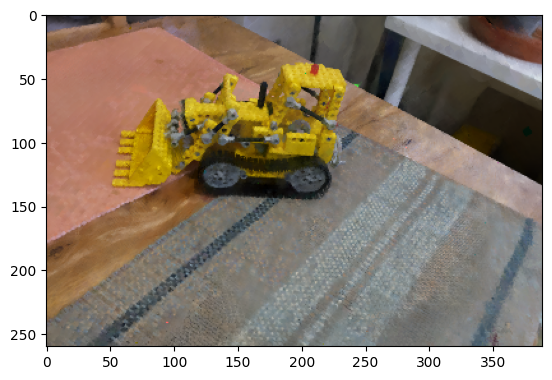

In [10]:
plt.imshow(rendered_img)

In [11]:
all_quantized_coefs[0].shape

torch.Size([53383, 3])

In [12]:
deltaQ = torch.exp2(encoder_test.trainable_params["log2_deltaQ"]).detach().cpu().numpy()
transformed_attributes = torch.concatenate(all_quantized_coefs).detach().cpu().numpy().astype(np.float64)

quantization_indices = np.round(
    np.array(transformed_attributes / deltaQ)
).astype(np.int64)


In [13]:
quantization_indices

array([[  19,   18,   18],
       [2053, 2100, 2173],
       [ 226,  378,  118],
       ...,
       [   0,    0,    0],
       [   0,    0,    0],
       [   0,    0,    0]])

In [14]:

# entropy coder
rate = 0
rate += rlgr.rlgr(quantization_indices[:, 0])
rate += rlgr.rlgr(quantization_indices[:, 1])
rate += rlgr.rlgr(quantization_indices[:, 2])

rate/ref_denfield.num_voxels

1.8245538245538246

In [ ]:
# p1 23.40178466942092, 2.476877476877477
# p2 22.39191041613933, 1.8245538245538246


In [ ]:
# iter = 3999 nvox = 53383 psnr = 20.455171800861184
# iter = 15999 nvox = 68384 psnr = 23.861671997851698
# iter = 26999 nvox = 144737 psnr = 24.82181125978562
# iter = 35999 nvox = 250556 psnr = 25.563771738778417
# iter = 42999 nvox = 431129 psnr = 26.16217433504914
# iter = 51999 nvox = 738494 psnr = 26.630531227057624
# iter = 59999 nvox = 1245585 psnr = 26.97370018154894
# iter = 87999 nvox = 1999998 psnr = 27.346640245272

#  iter003999_model, iter015999_model, iter026999_model, iter035999_model, iter042999_model, iter051999_model, iter059999_model, iter087999_model,

torch.cuda.empty_cache()
encoder = MultiScaleSplatsEncoder(
    scene_dataset_source_path="/home/dotamthuc-3090/Projects/ViewSynthesis/data/360_v2/kitchen/",
    list_density_field_paths=[
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter003999_model.pt",
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter015999_model.pt", # 1
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter026999_model.pt", # 2
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter035999_model.pt", # 3
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter042999_model.pt", # 4
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter051999_model.pt", # 5
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter059999_model.pt", # 6
        "/home/dotamthuc-3090/Projects/ViewSynthesis/result/kitchen-v04/checkpoints/iter087999_model.pt", # 7
    ],
    num_sample_per_voxel=1,
    deltaQ=0.001,
    lambda_rate=0.0,
    list_spread_b_init=[1.0, 0.2, 0.085, 0.05, 0.035, 0.025, 0.02, 0.015], 
    scene_loader_opt={
        "res_downscale": 8,
        "res_width": 0,
        "encoder_view_every": 20
    },
    A_transpose_opt={
        "lr": 0.001,
        "num_scene_loop": 30,
    },
    rotation_opt={
        "max_degree": 2,
        "muy_phi": 0.9,
    },
    encoding_opts={
        "lr": 0.001,
        "num_loop": 5,
        "dmode": "render_space" #coef_space / render_space
    },
    lowpass_rotation_opt = {
        "max_degree": 2,
        "muy_phi": 0.9,
    },
    lowpass_encoding_opts={
        "lr": 0.01,
        "num_loop": 5,
        "dmode": "render_space" #coef_space / render_space
    }
)

# END